In [106]:
import numpy as np                                          # Μαθηματική/αριθμητική βιβλιοθήκη
import scipy.io.wavfile as wav                              # Βιβλιοθήκη ανάγνωσης/εγγραφής ήχου
from scipy.stats import skew, kurtosis                      # Βιβλιοθήκη στατιστικών
import matplotlib.pyplot as plt                             # Βιβλιοθήκη απεικονίσεων
from IPython.display import Audio, display, Markdown        # Βιβλιοθήκη παιξίματος αρχείων ήχου

## Άσκηση - Μπορεί ο υπολογιστής να καταλάβει πως αισθανόμαστε "ακούγοντας" την ομιλία μας?

Ένα πολύ σημαντικό και ερευνητικά ανοιχτό πρόβλημα στον τομέα της Επικοινωνίας Ανθρώπου-Υπολογιστή είναι η **αναγνώριση του συναισθήματος ενός ομιλητή**. Το πρόβλημα αυτό είναι ιδιαίτερα πολύπλοκο και πιθανότατα λύνεται με πολυτροπικές μεθόδους (multi-modal approaches), δηλ. μεθόδους που λαμβάνουν υπ'όψη τα λόγια, την εικόνα (φωτογραφία ή βίντεο του ομιλητή), και την **προσωδία** του ομιλητή.

Στην άσκηση αυτή θα παίξουμε με μια πολύ απλή μέθοδο αναγνώρισης συναισθήματος από την ομιλία, χωρίς να λαμβάνουμε υπ'όψη τα λόγια αλλά μόνο την προσωδία, δηλ. το **πως** μιλάει κάποιος (την τονικότητα, το ρυθμό, το χρώμα, κλπ).

Φυσικά, ακόμα **δεν είστε σε θέση να καταλάβετε πολλά από αυτά αλλά ελπίζουμε να σας κεντρίσουμε το ενδιαφέρον**. 😊

*Ο κώδικας που θα χρειαστεί να γράψετε είναι ελάχιστος σε αυτήν την άσκηση. Καλείστε όμως να κατανοήσετε τη μεθοδολογία και (μερικώς, σε αδρές γραμμές) τον έτοιμο κώδικα.*

- **Βάση δεδομένων**:

Κατεβάστε τη βάση δεδομένων ```Berlin-EMOdB``` (https://zenodo.org/records/7447302), μια αρκετά παλιά και γνωστή βάση δεδομένων συναισθηματικής ομιλίας στα Γερμανικά με 535 συνολικά αρχεία WAV. Η ομιλία είναι *acted*, δηλ. δεν είναι φυσικού συναισθήματος αλλά υποκριτικού (από ηθοποιούς).

Τοποθετήστε τα .WAV αρχεία της σε ένα βολικό κατάλογο. Πάμε να σετάρουμε τα βασικά paths.

In [107]:
import re
from pathlib import Path

RNG_SEED = 1337
np.random.seed(RNG_SEED)

# -------------> Αλλάξτε το παρακάτω path ώστε να δείχνει στον κατάλογο wav της βάσης στο δίσκο σας: <-----------------
DATA_DIR = Path("./files/EmoDB/wav")

assert DATA_DIR.exists(), f"Δε βρίσκω τον κατάλογο: {DATA_DIR.resolve()}"

# Διαβάζουμε τα WAV files και τα κρατάμε σε μια λίστα με όνομα wav_files
wav_files = sorted(DATA_DIR.glob("*.wav"))

print(f"Βρήκαμε {len(wav_files)} WAV αρχεία στον κατάλογο {DATA_DIR.resolve()}")

Βρήκαμε 535 WAV αρχεία στον κατάλογο C:\Users\kafge\Documents\GitHub\SignalProcessing\Κώδικας\Python\Chapter11\files\EmoDB\wav


Αν όλα πήγαν καλά στο παραπάνω κελί και βρήκατε τα $535$ αρχεία που πρέπει, ας δούμε τη βάση δεδομένων αυτή **περιγραφικά**: πόσα αρχεία WAV έχει, πώς είναι οργανωμένη, πόσους ομιλητές έχει, πόσα συναισθήματα, κλπ.

Εδώ πρέπει να γνωρίζετε ότι η βάση αυτή περιγράφει τα αρχεία της με το εξής στυλ (ενδεικτικό αρχείο): `03a01Fa.wav`
Αυτή η ονοματοδοσία κωδικοποιεί τα πάντα για το αρχείο αυτό. Για παράδειγμα, το πρώτο '03' σημαίνει ότι μιλάει ο ομιλητής 03 και το γράμμα F δηλώνει το συναίσημα της "Χαράς".

Κάθε συναίσθημα κωδικοποιείται στο προτελευταίο γράμμα του WAV αρχείου ως εξής:

Σύμβολο : συναίσθημα (γερμανικό - ελληνικό όνομα)
- `W` : anger (Wut - Θυμός)
- `L` : boredom (Langeweile - Βαρεμάρα)
- `E` : disgust (Ekel - Αηδία)
- `A` : fear/anxiety (Angst - Φόβος)
- `F` : happiness (Freude - Χαρά)
- `T` : sadness (Trauer - Θλίψη)
- `N` : neutral (Ουδέτερο)

Ας ορίσουμε λοιπόν αυτήν την αντιστοίχιση και ας γράψουμε μια **κανονική έκφραση** (που ίσως ήδη ξέρετε ή αν όχι, θα μάθετε σε άλλα μαθήματα) για να εξάγουμε εύκολα αυτά τα στοιχεία από τη συμβολοσειρά του κάθε αρχείου WAV.

In [108]:
# Μοτίβο για κάθε όνομα αρχείου (regular expression (RE) - κανονική έκφραση):
PRIMARY_RE = re.compile(r"^(?P<spk>\d{2})(?P<txt>[a-z])(?P<utt>\d{2})(?P<emo>[A-Z])(?P<int>[a-z])\.wav$", re.IGNORECASE)

# Αντιστοίχιση
EMO_MAP = {
    "W": "Θυμός",
    "L": "Βαρεμάρα",
    "E": "Αηδία",
    "A": "Φόβος",
    "F": "Χαρά",
    "T": "Θλίψη",
    "N": "Ουδέτερο",
}

Πάμε να διαβάσουμε τα αρχεία της βάσης.

Ξεκινάμε δημιουργώντας μια συνάρτηση που εντοπίζει τον ομιλητή και το συναίσθημα με βάση το μοτίβο της ονοματοδοσίας του αρχείου που ορίσαμε παραπάνω.

In [109]:
def parse_emodb_filename(pathname):
    """
    Επιστρέφει (speaker_id, emotion_code)
    """
    m = PRIMARY_RE.match(pathname.name)  # έλεγξε το όνομα αρχείου με την regular expression ώστε να "ματσάρεις" τα στοιχεία
    spk = m.group("spk")                 # πάρε τον κωδικό ομιλητή
    emo = m.group("emo").upper()         # πάρε τον κωδικό συναισθήματος

    return spk, emo

Τώρα πάμε να προσπελάσουμε τον κατάλογο της βάσης διαβάζοντας κάθε WAV αρχείο και να χρησιμοποιήσουμε την παραπάνω συνάρτηση για την εξαγωγή πληροφορίας/κατηγοριοποίηση των αρχείων.

In [110]:
# ======= Προσπέλαση βασης ===========

# Μια λίστα για να κρατάμε πληροφορίες
rows = []

for wf in wav_files:                      # Για κάθε όνομα αρχείου στη λίστα wav_files που δημιουργήσαμε στην αρχή, στο πρώτο κελί της άσκησης...
    spk, emo = parse_emodb_filename(wf)   # ...βρες και πάρε τον κωδικό ομιλητή και τον κωδικό συναισθήματος από την ονοματοδοσία του αρχείου...
    sr, x = wav.read(str(wf))             # ...διάβασε και το WAV αρχείο και αποθήκευσέ το...
    n_samples = int(x.shape[0])
    dur = n_samples / float(sr)           # ...και υπολόγισε τη διάρκειά του σε δευτερόλεπτα

    # Μια λίστα από dictionaries για να κρατάμε πληροφορίες για κάθε αρχείο WAV
    rows.append({
        "Αρχείο": wf.name,
        "Ομιλητής": spk,
        "Κωδικός συναισθήματος": emo,
        "Συναίσθημα": EMO_MAP.get(emo, "UNKNOWN"),
        "Fs": int(sr),
        "Πλήθος δειγμάτων": n_samples,
        "Διάρκεια (s)": float(dur),
    })

Ας τυπώσουμε τι μάθαμε **γενικά** για τη βάση μας! 

In [111]:
# ====== Στατιστικά ======
speakers = [r["Ομιλητής"] for r in rows]
emos = [r["Κωδικός συναισθήματος"] for r in rows]
durations = np.array([r["Διάρκεια (s)"] for r in rows], dtype=float)
srs = np.array([r["Fs"] for r in rows], dtype=int)

print("\n=== Σύνοψη Βάσης Δεδομένων ===")
print("Πλήθος ομιλητών:", len(set(speakers)), sorted(set(speakers)))
print("Κωδικοί συναισθημάτων:", sorted(set(emos)))
print("Ονόματα συναισθημάτων:", [EMO_MAP.get(c, "UNKNOWN") for c in sorted(set(emos))])
print("Συχνότητα δειγματοληψίας (Hz):", sorted(set(srs.tolist())))


=== Σύνοψη Βάσης Δεδομένων ===
Πλήθος ομιλητών: 10 ['03', '08', '09', '10', '11', '12', '13', '14', '15', '16']
Κωδικοί συναισθημάτων: ['A', 'E', 'F', 'L', 'N', 'T', 'W']
Ονόματα συναισθημάτων: ['Φόβος', 'Αηδία', 'Χαρά', 'Βαρεμάρα', 'Ουδέτερο', 'Θλίψη', 'Θυμός']
Συχνότητα δειγματοληψίας (Hz): [16000]


Βλέπουμε λοιπόν - αν τα κάνατε όλα σωστά - ότι έχουμε 10 ομιλητές, 7 συναισθήματα, και όλα τα WAV αρχεία μας έχουν συχνότητα δειγματοληψίας 16000 Hz. Μια χαρά! 😉

Πάμε σε λίγο περισσότερο βάθος - μη βιάζεστε να προχωρήσουμε στην αναγνώριση του συναισθήματος! Η κατανόηση των δεδομένων που δουλεύουμε είναι σημαντική!

Πώς είναι κατανεμημένα τα WAV αρχεία ανά κλάση/συναίσθημα?

In [112]:
from collections import Counter

cc = Counter(emos) # μετράμε τα συναισθήματα και το πλήθος των WAV ανά συναίσθημα
N = sum(cc.values()) # το άθροισμά τους (535)

print("\nΠλήθος ηχογραφήσεων ανά κλάση:")

# Ας δούμε την κατανομή!
for c, k in sorted(cc.items(), key=lambda kv: (-kv[1], kv[0])):
    print(f"  {c} ({EMO_MAP.get(c,'UNKNOWN'):>8s}): {k:4d}  ({k/N:.2%})")


Πλήθος ηχογραφήσεων ανά κλάση:
  W (   Θυμός):  127  (23.74%)
  L (Βαρεμάρα):   81  (15.14%)
  N (Ουδέτερο):   79  (14.77%)
  F (    Χαρά):   71  (13.27%)
  A (   Φόβος):   69  (12.90%)
  T (   Θλίψη):   62  (11.59%)
  E (   Αηδία):   46  (8.60%)


Ενδιαφέρον! Κάθε συναίσθημα δεν έχει το ίδιο πλήθος αρχείων! Υπάρχει μια ανισοκατανομή στη *συγκεκριμένη* βάση δεδομένων ανά συναίσθημα. Αυτό είναι κάτι που πρέπει να γνωρίζουμε.

Ας δούμε τη διάρκεια σε δευτερόλεπτα κάθε αρχείου ανά κλάση/συναίσθημα.

In [113]:
print("\nΔιάρκεια ανά κλάση (δευτερόλεπτα):")
for c in sorted(set(emos)):
    d = np.array([r["Διάρκεια (s)"] for r in rows if r["Κωδικός συναισθήματος"] == c], dtype=float)
    print(f"  {c} ({EMO_MAP.get(c,'UNKNOWN'):>8s}): n={d.size:3d} "
          f"Μέσος όρος={d.mean():.3f}, Τυπ. απόκλιση={d.std():.3f}, Μεσαίος={np.median(d):.3f}, "
          f"Ελάχιστο={d.min():.3f}, Μέγιστο={d.max():.3f}")


Διάρκεια ανά κλάση (δευτερόλεπτα):
  A (   Φόβος): n= 69 Μέσος όρος=2.359, Τυπ. απόκλιση=0.634, Μεσαίος=2.206, Ελάχιστο=1.351, Μέγιστο=4.226
  E (   Αηδία): n= 46 Μέσος όρος=3.478, Τυπ. απόκλιση=1.062, Μεσαίος=3.242, Ελάχιστο=1.649, Μέγιστο=6.089
  F (    Χαρά): n= 71 Μέσος όρος=2.675, Τυπ. απόκλιση=0.675, Μεσαίος=2.589, Ελάχιστο=1.606, Μέγιστο=4.056
  L (Βαρεμάρα): n= 81 Μέσος όρος=2.904, Τυπ. απόκλιση=0.799, Μεσαίος=2.816, Ελάχιστο=1.645, Μέγιστο=4.651
  N (Ουδέτερο): n= 79 Μέσος όρος=2.486, Τυπ. απόκλιση=0.653, Μεσαίος=2.361, Ελάχιστο=1.556, Μέγιστο=4.024
  T (   Θλίψη): n= 62 Μέσος όρος=4.178, Τυπ. απόκλιση=1.520, Μεσαίος=3.988, Ελάχιστο=1.861, Μέγιστο=9.103
  W (   Θυμός): n=127 Μέσος όρος=2.767, Τυπ. απόκλιση=0.725, Μεσαίος=2.735, Ελάχιστο=1.591, Μέγιστο=5.338


Κι εδώ βλέπουμε ενδιαφέροντα πράγματα! Όμως είναι δύσκολο να αποκωδικοποιήσουμε τα νούμερα έτσι όπως παρουσιάζονται. Δε θα ήταν πιο εύκολο να τα οπτικοποιήσουμε?

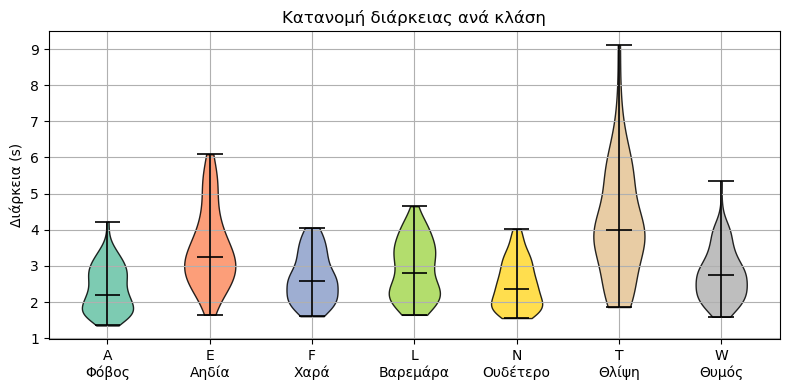

In [114]:
# Πόσα συναισθήματα έχουμε?
classes = sorted(set(emos))

# Ας μαζέψουμε τις διάρκειες ανά κλάση/συναίσθημα
data = [np.array([r["Διάρκεια (s)"] for r in rows if r["Κωδικός συναισθήματος"] == c], dtype=float)
        for c in classes]

# Οπτικοποίηση με violin plot
plt.figure(figsize=(8, 4))
vp = plt.violinplot(data, showmeans=False, showmedians=True, showextrema=True)

# Χρώματα από colormap (π.χ. tab10 / Set2 / viridis)
cmap = plt.cm.Set2
colors = cmap(np.linspace(0, 1, len(classes)))

for body, col in zip(vp["bodies"], colors):
    body.set_facecolor(col)
    body.set_edgecolor("black")
    body.set_alpha(0.85)

# Γραμμές (median/extrema) – εδώ τις κάνουμε ίδιες για όλα τα σχήματα (π.χ. μαύρες)
for k in ("cmedians", "cmins", "cmaxes", "cbars"):
    if k in vp:
        vp[k].set_color("black")
        vp[k].set_linewidth(1.2)

# Ομορφαίνουμε
plt.xticks(np.arange(1, len(classes)+1), [f"{c}\n{EMO_MAP.get(c,'UNKNOWN')}" for c in classes])
plt.ylabel("Διάρκεια (s)")
plt.title("Κατανομή διάρκειας ανά κλάση")
plt.tight_layout()
plt.grid()
plt.show()

#### Ερώτηση: **Σε αυτή ΚΑΙ ΜΟΝΟ ΑΥΤΗ τη βάση δεδομένων**, τι καταλαβαίνουμε για την κατανομή της διάρκειας των συναισθημάτων? Γράψτε παρακάτω τη σκέψη σας.

#### Απάντηση:

Το συναίσθημα της θλίψης έχει τη μεγαλύτερη μέση διάρκεια και γενικότερα η κατανομή της δείχνει ότι ο αργός τρόπος ομιλίας που χρησιμοποιούμε όταν μιλάμε θλιμμένοι/ες αποτυπώνεται. Η χαρά, το ουδέτερο, και ο φόβος έχουν την πιο "συμμαζεμένη διάρκεια". Η αηδία φαίνεται να έχει επίσης μεγαλύτερες κατά μέσο όρο διάρκειες από τα υπόλοια.

Κλείνοντας αυτήν την περιήγηση στα δεδομένα μας, ας δούμε και πως κατανέμονται οι ομιλητές ανά συναίσθημα.

In [115]:
from collections import Counter, defaultdict

# ====== Ομιλητής x Κλάση ======
spk_class = defaultdict(Counter)
for r in rows:
    spk_class[r["Ομιλητής"]][r["Κωδικός συναισθήματος"]] += 1

classes_sorted = sorted(set(emos))
header = "Ομιλητής " + " ".join([f"{c:>6s}" for c in classes_sorted]) + " | Σύνολο"

print("\nΟμιλητής × Κατανομή κλάσεων:")

print(header)

print("-" * len(header))
for spk in sorted(spk_class.keys()):
    total = sum(spk_class[spk].values())
    row = f"{spk:>7s} " + " ".join([f"{spk_class[spk].get(c,0):6d}" for c in classes_sorted]) + f"  |{total:5d}"
    print(row)


Ομιλητής × Κατανομή κλάσεων:
Ομιλητής      A      E      F      L      N      T      W | Σύνολο
------------------------------------------------------------------
     03      4      1      7      5     11      7     14  |   49
     08      6      0     11     10     10      9     12  |   58
     09      1      8      4      4      9      4     13  |   43
     10      8      1      4      8      4      3     10  |   38
     11     10      2      8      8      9      7     11  |   55
     12      6      2      2      5      4      4     12  |   35
     13      7      8     10     10      9      5     12  |   61
     14     12      8      8      8      7     10     16  |   69
     15      8      5      6      9     11      4     13  |   56
     16      7     11     11     14      5      9     14  |   71


Εδώ παρατηρούμε ότι ο ομιλητής $16$ έχει δώσει τα περισσότερα συνολικά δείγματα ($71$), ενώ ο ομιλητής $12$ τα λιγότερα ($35$). Επίσης, ο ομιλητής $08$ δεν έχει δώσει *κανένα* δείγμα από το συναίσθημα της Αηδίας (Ε), ενώ ο ομιλητής $14$ έχει δώσει τα περισσότερα δείγματα σε οποιαδήποτε κλάση, με $16$ στην κλάση του Θυμού (W). Τέλος, όλοι οι ομιλητές έδωσαν *πολλά* δείγματα στην κλάση του Θυμού, γι' αυτό και έχουμε ανισορροπία στις κλάσεις, με το Θυμό να έχει $127$ συνολικά δείγματα.

Ώρα είναι να ακούσουμε και μερικά τυχαία δείγματα!

In [116]:
rng = np.random.default_rng(1337)

r0 = rows[0]

def get_key(d, options):
    for k in options:
        if k in d:
            return k

k_emo = get_key(r0, ["Κωδικός συναισθήματος"])
k_file = get_key(r0, ["Αρχείο", "Όνομα αρχείου"])

def to_path(v):
    p = Path(v)
    return p if p.is_absolute() else (DATA_DIR / p)

classes = sorted({r[k_emo] for r in rows})

for c in classes:
    subset = [r for r in rows if r[k_emo] == c]
    rep = subset[int(rng.integers(0, len(subset)))]
    wav_path = to_path(rep[k_file])
    emo_name = EMO_MAP.get(c, c) if "EMO_MAP" in globals() else str(c)
    display(Markdown(f"### {c} — {emo_name}\n`{wav_path.name}`"))
    display(Audio(filename=str(wav_path)))

### A — Φόβος
`13a04Ac.wav`

### E — Αηδία
`16a07Ea.wav`

### F — Χαρά
`14b01Fc.wav`

### L — Βαρεμάρα
`09a02La.wav`

### N — Ουδέτερο
`11b10Nc.wav`

### T — Θλίψη
`16a07Td.wav`

### W — Θυμός
`11a01Wc.wav`

Ακόμα κι αν δεν ξέρετε Γερμανικά, ο εγκέφαλός σας πρέπει να καταλαβαίνει το φερόμενο συναίσθημα. Και πόσο εύκολα το κάνει!... 😯

Παρ' όλο που υπάρχουν μέθοδοι που μπορούν να βγάλουν καλά αποτελέσματα, εσείς δεν τις γνωρίζετε και επίσης δε γνωρίζετε τα χαρακτηριστικά που πρέπει να εξάγετε.

Ας απλοποιήσουμε το πρόβλημα λοιπόν. Ας κρατήσουμε μόνο **ΤΕΣΣΕΡΑ** ($4$) συναισθήματα:

#### *Θυμό, Χαρά, Φόβος, και Ουδέτερο*

για το προβλημά μας.

In [129]:
# Λίστες για να κρατήσουμε μόνο αυτά που είπαμε
speaker_ids = []
emotion_codes = []
kept_files = []

# Επαναλαμβάνουμε το ίδιο με πριν
for wf in wav_files:
    spk, emo = parse_emodb_filename(wf)
    speaker_ids.append(spk)
    emotion_codes.append(emo)
    kept_files.append(wf)

# Κρατάμε μόνο ΤΕΣΣΕΡΑ συναισθήματα - Θυμός, Ουδέτερο, Χαρά, Φόβος (δοκιμάστε να παίξετε με αυτά!)
KEEP = {"W", "N", "F", "A"}

# Κρατάμε μόνο ομιλητές, αρχεία, και κωδικούς συναισθημάτων που αφορούν τα τέσσερα παραπάνω συναισθήματα
filtered = [(wf, spk, emo) for wf, spk, emo in zip(kept_files, speaker_ids, emotion_codes) if emo in KEEP]
kept_files, speaker_ids, emotion_codes = map(list, zip(*filtered)) if filtered else ([], [], [])

print(f"Κρατήσαμε: {len(kept_files)} files")
print("Συναισθήματα και πλήθος WAV σε καθένα:", Counter(emotion_codes))
print("Ομιλητές:", sorted(set(speaker_ids)))

Κρατήσαμε: 346 files
Συναισθήματα και πλήθος WAV σε καθένα: Counter({'W': 127, 'N': 79, 'F': 71, 'A': 69})
Ομιλητές: ['03', '08', '09', '10', '11', '12', '13', '14', '15', '16']


- **Εξαγωγή χαρακτηριστικών**:

Παρ' όλο που υπάρχουν ΠΑΡΑ ΠΟΛΛΑ χαρακτηριστικά που μπορεί κανείς να εξάγει από την ομιλία, εδώ θα χρησιμοποιήσουμε **δύο** απλά αλλά χρήσιμα, υπολογισμένα ανά παράθυρο (frame) στο **διακριτό χρόνο**: την **RMS ενέργεια** και τον **ρυθμό διελεύσεων από το μηδέν (Zero-Crossing Rate, ZCR)**.

Ξεκινάμε από την **Root Mean-Square Ενέργεια**. Για ένα frame $x[n]$ διακριτού χρόνου με $N$ δείγματα ($n = 0, 1, \dots, N-1$) ορίζεται ως

$$\boxed{\mathrm{RMS}_{\text{energy}} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1} x^2[n]}}$$

Είναι δηλαδή η τετραγωνική ρίζα της **μέσης ισχύος** του frame. Έχει κάμποσα πλεονεκτήματα σε σχέση με την "απλή" ενέργεια (το σκέτο άθροισμα των τετραγώνων $\sum_n x^2[n]$), ειδικά όταν θέλουμε να χτίσουμε αλγορίθμους που "μαθαίνουν" από αυτή, καθώς **δεν εξαρτάται από το πλήθος δειγμάτων $N$** του frame.

Υλοποιήστε παρακάτω μια συνάρτηση που υπολογίζει την RMS ενέργεια - όπως τη βλέπετε πιο πάνω, με το άθροισμα - για κάθε frame ομιλίας (**εδώ πρέπει να συμπληρώσετε κώδικα**).

In [118]:
def rms_energy(frame):
    N = len(frame)
    under_root = (1/N) * np.sum(frame**2, axis=1) # χρησιμοποιήστε τη np.sum και το σύμβολο ** για την ύψωση σε δύναμη,
                 # και προσθέστε axis=1 σαν τελευταίο όρισμα της np.sum

    return np.sqrt(under_root + 1e-12)

# Test:
test_signal = np.asarray([[1.1, 2.2], [-1, -9]])
print(rms_energy(test_signal)) # πρέπει να πάρετε [1.73925271 6.40312424]

[1.73925271 6.40312424]


Το δεύτερο χαρακτηριστικό μας είναι ο **Ρυθμός Διελεύσεων από το Μηδέν** (Zero-Crossing Rate, ZCR).

Μια **διέλευση από το μηδέν** (zero-crossing) σε ένα σήμα διακριτού χρόνου $x[n]$ συμβαίνει όποτε δυο **διαδοχικά** δείγματα έχουν **αντίθετο πρόσημο**, δηλαδή όποτε το σήμα "περνάει" τον οριζόντιο άξονα ανάμεσα στα δείγματα $n-1$ και $n$.

Ορίζουμε πρώτα τη **συνάρτηση προσήμου**:

$$\operatorname{sgn}(x[n]) = \begin{cases} +1, & x[n] \ge 0 \\ -1, & x[n] < 0 \end{cases}$$

Τότε το **πλήθος** των διελεύσεων από το μηδέν μέσα σε ένα frame $N$ δειγμάτων είναι

$$Z = \frac{1}{2}\sum_{n=1}^{N-1}\bigl|\operatorname{sgn}(x[n]) - \operatorname{sgn}(x[n-1])\bigr|$$

Σκεφτείτε ότι κάθε αλλαγή προσήμου κάνει τη διαφορά $|\operatorname{sgn}(x[n]) - \operatorname{sgn}(x[n-1])|$ ίση με $2$, ενώ κάθε μη-αλλαγή την κάνει $0$.

Για να μην εξαρτάται η τιμή από το μήκος του frame, **κανονικοποιούμε** διαιρώντας με το πλήθος $N-1$ των ζευγών γειτονικών δειγμάτων:

$$\boxed{\;\mathrm{ZCR} = \dfrac{Z}{N-1} = \frac{1}{2(N-1)}\sum_{n=1}^{N-1}\bigl|\operatorname{sgn}(x[n]) - \operatorname{sgn}(x[n-1])\bigr|\in [0, 1]\;}$$

Ο ZCR είναι ένα φθηνό υπολογιστικά μέτρο του πόσο "γρήγορα" αλλάζει πρόσημο το σήμα, δηλ. ένας **έμμεσος δείκτης του κυρίαρχου συχνοτικού περιεχομένου**: υψηλός ZCR σημαίνει έντονο υψίσυχνο/θορυβώδες περιεχόμενο (π.χ. άφωνα σύμφωνα όπως το /s/, /f/), ενώ χαμηλός ZCR σημαίνει χαμηλόσυχνο/έμφωνο περιεχόμενο (π.χ. φωνήεντα). Πρόχειρα, για ένα ημιτονοειδές σήμα συχνότητας $f_0$ που δειγματοληπτείται με ρυθμό $F_s$, ισχύει $\mathrm{ZCR}\cdot F_s \approx 2f_0$.

Υλοποιήστε παρακάτω μια συνάρτηση που υπολογίζει τον ZCR για **κάθε γραμμή (frame)** ενός διδιάστατου πίνακα, ακριβώς όπως κάνει η ```rms_energy``` (**εδώ πρέπει να συμπληρώσετε κώδικα**).

In [119]:
def zero_crossing_rate(frames):
    N = frames.shape[1]             # μήκος κάθε frame σε δείγματα
    s = np.sign(frames)             # πρόσημο κάθε δείγματος: +1, 0 ή -1
    s[s == 0] = 1                   # σύμβαση: τα ακριβώς-μηδενικά δείγματα τα θεωρούμε θετικά (+1)

    # Πλήθος αλλαγών προσήμου ανά frame: παίρνουμε διαφορές γειτονικών προσήμων (np.diff),
    # απόλυτη τιμή, άθροισμα κατά μήκος του axis=1, και διαιρούμε με 2 (κάθε αλλαγή δίνει |διαφορά|=2)
    crossings = np.sum(np.abs(np.diff(s, axis=1)), axis=1) / 2.0

    return crossings / (N - 1)      # κανονικοποίηση -> ρυθμός στο [0, 1]

# Test:
test_frames = np.asarray([[1, -1, 1, -1], [1, 1, -1, -1]], dtype=float)
print(zero_crossing_rate(test_frames)) # πρέπει να πάρετε [1.         0.33333333]

[1.         0.33333333]


Αν πριν φτάσετε εδώ, λύσατε την άσκηση με τον ανιχνευτή δραστηριότητας ομιλίας ($\texttt{Ex-SimpleVAD}$), θα προσέξατε ότι χρησιμοποιήσαμε την ενέργεια ανά frame *χωρίς επικάλυψη* των γειτονικών frames. Όμως στην πραγματικότητα, κάποια επικάλυψη είναι πολλές φορές χρήσιμη για να παρακολουθούμε στενότερα την εξέλιξη των τιμών προϊόντος του χρόνου. Γι' αυτό λοιπόν θα υιοθετήσουμε μια τέτοια προσέγγιση, όπου θα υπάρχει επικάλυψη κατά $50\%$ μεταξύ των γειτονικών frames.

Σας δίνεται παρακάτω έτοιμη συνάρτηση που σας επιστρέφει ένα διδιάστατο πίνακα, όπου σε κάθε γραμμή του έχετε κι ένα frame διάρκειας $30$ ms (σε δείγματα διακριτού χρόνου), με επικάλυψη $15$ ms με το προηγούμενό του.

In [120]:
def frame_signal(x, frame_len, hop):
    """
    Επιστρέφει έναν 2Δ πίνακα (n_frames, frame_len) που σε κάθε γραμμή του έχει ένα frame διάρκειας
    frame_len δειγμάτων του συνολικού σήματος φωνής.

    Αν τα frames που θέλουμε δε "χωράνε" στο συνολικό σήμα, γίνεται ένα μικρό padding στο τέλος.
    """
    if len(x) < frame_len:
        x = np.pad(x, (0, frame_len - len(x)), mode="reflect")

    n_frames = 1 + int(np.ceil((len(x) - frame_len) / hop))
    total_len = (n_frames - 1) * hop + frame_len
    if total_len > len(x):
        x = np.pad(x, (0, total_len - len(x)), mode="reflect")

    shape = (n_frames, frame_len)
    strides = (x.strides[0] * hop, x.strides[0])

    return np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

Αν λοιπόν καλέσουμε

```E = rms_energy(frame_signal(x, ...))```

θα πάρουμε ένα διάνυσμα ```E``` που θα έχει μια τιμή ενέργειας για κάθε frame ενός σήματος ομιλίας, δηλ. $N$ τιμές, όσες και τα frames. Αντίστοιχα, καλώντας

```Z = zero_crossing_rate(frame_signal(x, ...))```

θα πάρουμε ένα διάνυσμα ```Z``` με μια τιμή ZCR για κάθε frame. Έχουμε λοιπόν **δυο "καμπύλες"** ανά σήμα φωνής: μία της ενέργειας και μία του ZCR.

Καταλαβαίνετε όμως οτι

- Κάθε σήμα φωνής έχει τη δική του διάρκεια, δηλ. το πλήθος των frames του δεν είναι σταθερό.

- Το να χρησιμοποιήσουμε όλες τις τιμές (ενέργειας ή ZCR) για κάθε σήμα φωνής δε μας βοηθά. Πολλές τιμές, με μεγάλη συσχέτιση μεταξύ τους (πόση διαφορά να έχει η ενέργεια μεταξύ δυο γειτονικών frames ???).

Θα θέλαμε να **συνοψίσουμε στατιστικά** κάθε "καμπύλη" για κάθε σήμα φωνής. Έτσι θα φτιάξουμε ένα νέο, *μικρότερο* διάνυσμα που περιγράφει στατιστικά το σήμα φωνής μέσω των χαρακτηριστικών του!

Πώς θα μπορούσαμε να περιγράψουμε στατιστικά τις τιμές μιας τέτοιας "καμπύλης" (π.χ. της ενέργειας) ενός σήματος?

- Η **μέση τιμή** των τιμών θα ήταν μια καλή ιδέα. Αρκεί? Μάλλον όχι.

- Αν προσθέταμε και την **τυπική απόκλιση** των τιμών? Κάπως καλύτερα... τι άλλο μπορούμε να βάλουμε?

- Τη **μεσαία τιμή** (median) επίσης.

Χμμμ... φτάνουν? Μπορεί, μπορεί και όχι. Ας προσθέσουμε μερικά ακόμα:

- **Ασυμμετρία (skewness)**: μετρά από ποιά μεριά βρίσκεται η "ουρά" της κατανομής των τιμών. Θετική ασσυμετρία σημαίνει ότι η "ουρά" της κατανομής βρίσκεται προς τα δεξιά.

- **Κυρτότητα (kurtosis)**: περιγράφει ένα μέτρο που αφορά το σχήμα των "ουρών" της κατανομής σε σχέση με το συνολικό της σχήμα. Υψηλή κυρτότητα σημαίνει ότι οι "ουρές" της κατανομής είναι έντονες, υπάρχουν αρκετές τιμές στα άκρα της κατανομής.

Μέχρι τώρα έχουμε πέντε ($5$) στατιστικές τιμές ανά "καμπύλη". Ούτε πολλές, ούτε λίγες. Υπάρχει ακόμα μια γνωστή τετράδα στατιστικών. Ας τη βάλουμε κι αυτή.

- **p10 (10ο εκατοστημόριο)**: Η τιμή κάτω από την οποία βρίσκεται το $10\%$ των τιμών (δηλαδή "οι πιο χαμηλές τιμές").

- **q25 (25ο εκατοστημόριο)**: Η τιμή κάτω από την οποία βρίσκεται το $25\%$ των τιμών.

- **q75 (75ο εκατοστημόριο)**: Η τιμή κάτω από την οποία βρίσκεται το $75\%$ των τιμών.

- **p90 (90ο εκατοστημόριο)**: Η τιμή κάτω από την οποία βρίσκεται το $90\%$ των τιμών (δηλαδή "οι πιο υψηλές τιμές").

Παρακάτω σας δίνεται μια συνάρτηση που υπολογίζει και τα εννέα ($9$) αυτά στατιστικά από μια "καμπύλη" τιμών ενός σήματος φωνής (**εδώ πρέπει να συμπληρώσετε κώδικα**).

In [121]:
def summarize_stats(value_vector):
    """
    Στατιστικά πάνω σε ένα διάνυσμα εισόδου value_vector (π.χ. την "καμπύλη" ενέργειας ή ZCR)

    Επιστρέφει, με τη σειρά:
      mean, std, skewness, kurtosis, median, p10, q25, q75, p90
    """
    ev = np.asarray(value_vector, dtype=float).ravel()
    n = ev.size
    if n == 0:
        return np.zeros(9, dtype=float)

    mu = float(np.mean(ev))  # Κάντε χρήση της ev και της numpy function για τη μέση τιμή (mean) - κάντε cast σε float στο τέλος
    sd = float(np.std(ev))  # Κάντε χρήση της ev και της numpy function για την τυπική απόκλιση (standard deviation) - κάντε cast σε float στο τέλος
    med = float(np.median(ev)) # Κάντε χρήση της ev και της numpy function για το μεσαίο όρο (median) - κάντε cast σε float στο τέλος

    p10, q25, q75, p90 = np.percentile(ev, [10, 25, 75, 90]) # τα εκατοστημόρια

    if sd > 1e-12:
        sk = float(skew(ev, bias=False))                     # Ασυμμετρία
        ku = float(kurtosis(ev, fisher=True, bias=False))    # Κύρτωση
    else:
        sk, ku = 0.0, 0.0                                    # ...σε περίπτωση που δεν ορίζονται καλώς

    return np.array([mu, sd, sk, ku, med, float(p10), float(q25), float(q75), float(p90)], dtype=float)

# Ας κωδικοποιήσουμε τα ονόματα. Τα ΙΔΙΑ 9 στατιστικά τα υπολογίζουμε ΚΑΙ για την ενέργεια (E_*) ΚΑΙ για τον ZCR (Z_*)
FUNC_NAMES = ["mean", "std", "skew", "kurt", "median", "p10", "q25", "q75", "p90"]
feature_names = [f"E_{s}" for s in FUNC_NAMES] + [f"Z_{s}" for s in FUNC_NAMES]
print("n_features =", len(feature_names), feature_names)  # 18 χαρακτηριστικά: 9 ενέργειας + 9 ZCR

n_features = 18 ['E_mean', 'E_std', 'E_skew', 'E_kurt', 'E_median', 'E_p10', 'E_q25', 'E_q75', 'E_p90', 'Z_mean', 'Z_std', 'Z_skew', 'Z_kurt', 'Z_median', 'Z_p10', 'Z_q25', 'Z_q75', 'Z_p90']


Ας φτιάξουμε μια συνάρτηση ```extract_features``` που να δέχεται ένα path για ένα σήμα φωνής και να εξάγει, frame-by-frame, **δύο** "καμπύλες" (RMS ενέργειας και ZCR), και στη συνέχεια να συνοψίζει **καθεμιά** με τα παραπάνω $9$ στατιστικά, δίνοντας συνολικά $9 + 9 = 18$ χαρακτηριστικά! (**Εδώ πρέπει να συμπληρώσετε κώδικα**).

In [122]:
def extract_features(wav_path, frame_ms=30.0, hop_ms=15.0):
    """
    Εξάγει, ανά frame, την RMS ενέργεια ΚΑΙ τον ZCR από ένα σήμα φωνής,
    και μετά τα 9 στατιστικά για ΚΑΘΕ μία από τις δυο "καμπύλες".

    Επιστρέφει ένα διάνυσμα 18 χαρακτηριστικών: [9 ενέργειας | 9 ZCR].
    """
    sr, x = wav.read(wav_path)  # Διαβάζουμε το σήμα φωνής
    x = np.asarray(x)           # Safety :)

    # Κανονικοποίηση
    info = np.iinfo(x.dtype)
    denom = float(max(abs(info.min), abs(info.max)))
    x = x.astype(np.float32) / denom
    x = np.clip(x, -1.0, 1.0)

    # Παράμετροι για τη frame-by-frame ανάλυση
    frame_len = int(round(sr * frame_ms / 1000.0)) # Μετατρέπουμε τα 30 ms σε δείγματα: 480
    hop = int(round(sr * hop_ms / 1000.0))         # Μετατρέπουμε τα 15 ms σε δείγματα: 240
    frames = frame_signal(x, frame_len=frame_len, hop=hop) # Καλούμε την frame_signal για την τμηματοποίηση του σήματος

    e = rms_energy(frames)             # "καμπύλη" ενέργειας ανά frame (καλώντας κατάλληλη συνάρτηση)
    z = zero_crossing_rate(frames)     # "καμπύλη" ZCR ανά frame (καλώντας κατάλληλη συνάρτηση)

    e_stats = summarize_stats(e)       # 9 στατιστικά της "καμπύλης" ενέργειας
    z_stats = summarize_stats(z)       # 9 στατιστικά της "καμπύλης" ZCR

    return np.concatenate([e_stats, z_stats])   # 18 χαρακτηριστικά: πρώτα τα 9 της ενέργειας, μετά τα 9 του ZCR

# Testing
feats = extract_features(kept_files[0])
print(feats.shape) # Πρέπει να είναι (18,)  ->  9 ενέργειας + 9 ZCR
print(feats) # Θα πρέπει να πάρετε [7.83203290e-02 1.00734544e-01 2.05576550e+00 5.07797727e+00
# 4.08517681e-02 9.99999997e-07 2.99461547e-03 1.20886039e-01
# 1.88333279e-01 1.00812751e-01 1.36680349e-01 2.42127987e+00
# 6.06477540e+00 5.84551133e-02 0.00000000e+00 1.77453030e-02
# 1.13778703e-01 2.36325675e-01]

(18,)
[7.83203290e-02 1.00734544e-01 2.05576550e+00 5.07797727e+00
 4.08517681e-02 9.99999997e-07 2.99461547e-03 1.20886039e-01
 1.88333279e-01 1.00812751e-01 1.36680349e-01 2.42127987e+00
 6.06477540e+00 5.84551133e-02 0.00000000e+00 1.77453030e-02
 1.13778703e-01 2.36325675e-01]


- **Κατασκευή χαρακτηριστικών για όλη τη βάση δεδομένων**:

Όλα τώρα είναι έτοιμα! Πρέπει να κάνουμε την παραπάνω διαδικασία για ΚΑΘΕ σήμα φωνής στη βάση. Μαζί με τα $18$ στατιστικά χαρακτηριστικά, πρέπει να κρατήσουμε:

1. Τον κωδικό συναισθήματος που αντιστοιχεί σε κάθε WAV (που όμως πλέον κωδικοποιείται όπως είπαμε από τα $18$ στατιστικά)

2. Τον κωδικό ομιλητή (το γιατί θα το καταλάβετε σε λίγο)

In [ ]:
# Λίστες που μαζεύουμε τα δεδομένα μας
data = []      # εδώ μαζεύουμε τα 18 χαρακτηριστικά για κάθε πρόταση
label = []     # εδώ μαζεύουμε τον κωδικό συναισθήματος για κάθε πρόταση - είναι το ground truth για κάθε πρόταση
speakers = []    # εδώ μαζεύουμε τον κωδικό ομιλητή για κάθε πρόταση

# Ξεκινάμε!
for wf, spk, emo in zip(kept_files, speaker_ids, emotion_codes):
        data.append(extract_features(wf)) # αποθηκεύουμε τα 18 χαρακτηριστικά για το σήμα στο path wf
        label.append(emo)                 # ...το label (συναίσθημα) του ...
        speakers.append(spk)              # ...και τον κωδικό ομιλητή του

# Από λίστες, τα κάνουμε numpy arrays
data = np.asarray(data, dtype=float)
label = np.asarray(label)
speakers = np.asarray(speakers)

# Απλό τσεκάρισμα ότι όλα είναι καλά
print("Data shape:", data.shape)                    # [277 προτάσεις x 18 χαρακτηριστικά]
print("Μοναδικά συναισθήματα:", sorted(set(label))) # 4 συναισθήματα
print("Μοναδικοί ομιλητές:", sorted(set(speakers))) # 10 ομιλητές

Data shape: (346, 18)
Μοναδικά συναισθήματα: ['A', 'F', 'N', 'W']
Μοναδικοί ομιλητές: ['03', '08', '09', '10', '11', '12', '13', '14', '15', '16']


- **Διαχωρισμός βάσης σε train & test**:

Έχουμε λοιπόν στα ```data, label, speakers``` ΟΛΑ ΟΣΑ θέλουμε!

Τώρα πρέπει να τα χωρίσουμε σε **δυο ξένα σύνολα**, ένα για να **εκπαιδεύσουμε ένα μοντέλο μηχανικής μάθησης** (training set) κι ένα για να **ελέγξουμε τις *επιδόσεις* του μοντέλου** (test set).

Ο διαχωρισμός αυτός δεν μπορεί/δεν πρέπει να είναι εντελώς τυχαίος! Πρέπει

(α) ο τυχαίος διαχωρισμός να αντικατοπτρίζει την κατανομή των συναισθημάτων της βάσης στα δυο υποσύνολα training και test.

(β) ο τυχαίος διαχωρισμός να σέβεται το γεγονός ότι κάθε ομιλητής πρέπει να βρίσκεται είτε στο training set είτε στο test set! Αν κάποια δείγματα κάποιου ομιλητή βρίσκονται και στα δυο set, η απόδοση της αναγνώρισης του συναισθήματος είναι πολύ καλύτερη από την πραγματικότητα γιατί το μοντέλο έχει "δει" στην εκπαίδευσή του κάποιον ομιλητή που βρίσκεται στο, υποτίθεται άγνωστο, test set.

Ευτυχώς η ```Python``` έχει έτοιμη συνάρτηση που κάνει αυτό το διαχωρισμό με βάση τη μεταβλητή ```speakers``` που έχουμε δημιουργήσει, την ```StratifiedGroupKFold``` του πακέτου ```scikit-learn```!

Απλά τρέξτε το παρακάτω κελί, μη δώσετε σημασία στις λεπτομέρειες. Η ουσία είναι ότι η συνάρτηση αυτή δημιουργεί δυο **δείκτες** στο αρχικό σύνολο των δεδομένων μας, που σέβονται τις δυο παραπάνω προϋποθέσεις.

In [124]:
from sklearn.model_selection import StratifiedGroupKFold

# Χωρίζουμε τα δυο σετ, training & test, με βάση τους speakers και την αρχική κατανομή συναισθημάτων της βάσης
def stratified_group_split(labels, speakers, seed=1337):
    n = len(labels)

    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)

    for tr, te in sgkf.split(np.zeros(n), labels, speakers):
        return np.asarray(tr), np.asarray(te)

Η συνάρτηση αυτή επιστρέφει δυο πίνακες:

1. Έναν που περιέχει τους **δείκτες** στους πίνακες ```data```, ```label```, ```speakers``` που αντιστοιχούν στο training set. Αυτό αποτελεί περίπου το $80\%$ της επιλεγμένης βάσης.

2. Έναν που περιέχει τους **δείκτες** στους πίνακες ```data```, ```label```, ```speakers``` που αντιστοιχούν στο test set. Αυτό αποτελεί περίπου το $20\%$ της επιλεγμένης βάσης.

Ας τη δοκιμάσουμε!

In [125]:
train_idx, test_idx = stratified_group_split(label, speakers, seed=RNG_SEED)

print(f"Μέγεθος training set: {len(train_idx)}, Μέγεθος test set: {len(test_idx)}\n")
print("Πλήθος ομιλητών στο training set:", sorted(set(speakers[train_idx])))
print("Πλήθος ομιλητών στο test set: ", sorted(set(speakers[test_idx])))

# Ας δούμε το ποσοστό αναλογίας κάθε συναισθήματος σε κάθε σετ (train & test)
def show_props(idx, name):
    labs = sorted(set(label))
    props = {lab: float(np.mean(label[idx] == lab)) for lab in labs}
    print(name, props)

# Ένα cross-check
show_props(np.arange(len(label)), "\nΣυνολική βάση:")
show_props(train_idx, "Training  ")
show_props(test_idx,  "Test   ")

Μέγεθος training set: 283, Μέγεθος test set: 63

Πλήθος ομιλητών στο training set: ['03', '09', '10', '11', '13', '14', '15', '16']
Πλήθος ομιλητών στο test set:  ['08', '12']

Συνολική βάση: {'A': 0.1994219653179191, 'F': 0.20520231213872833, 'N': 0.22832369942196531, 'W': 0.3670520231213873}
Training   {'A': 0.20141342756183744, 'F': 0.2049469964664311, 'N': 0.22968197879858657, 'W': 0.36395759717314485}
Test    {'A': 0.19047619047619047, 'F': 0.20634920634920634, 'N': 0.2222222222222222, 'W': 0.38095238095238093}


Βλέπετε ότι οι αναλογίες ανά συναίσθημα είναι κοντά στην αρχική αναλογία της βάσης, δεδομένης και της κατανομής των ομιλητών ανά συναίσθημα:

Συνολικη βάση: {'A': $20\%$, 'F': $20\%$, 'N': $22\%$, 'W': $36\%$}

Training:      {'A': $20\%$, 'F': $20\%$, 'N': $23\%$, 'W': $36\%$}

Test:          {'A': $19\%$, 'F': $20\%$, 'N': $22\%$, 'W': $38\%$} 

- **Εκπαίδευση Μοντέλου Μηχανικής Μάθησης**:

Φτάσαμε στο επιθυμητό σημείο. Τώρα πρέπει απλά να επιλέξουμε ένα μοντέλο μηχανικής μάθησης και να το εκπαιδεύσουμε με τα χαρακτηριστικά που φτιάξαμε: τα $18$ στατιστικά κάθε πρότασης, μαζί με τον κωδικό συναισθήματος, ώστε να μάθει την αντιστοιχία

<p style="text-align:center;">
τα 18 χαρακτηριστικά της i-οστής πρότασης αντιστοιχούν στο j-οστό συναίσθημα
</p>

Από τα πραγματικά ΠΑΡΑ ΠΟΛΛΑ μοντέλα, θα επιλέξουμε τη **Μηχανή Διανυσμάτων Υποστήριξης με πυρήνα RBF (RBF-kernel Support Vector Machine, SVM)**.

Με *απλά λόγια*: μια SVM προσπαθεί να βρει το "σύνορο απόφασης" (decision boundary) που **χωρίζει τις κλάσεις με το μεγαλύτερο δυνατό περιθώριο** (margin). Τα δείγματα που ακουμπούν αυτό το περιθώριο και το καθορίζουν λέγονται **διανύσματα υποστήριξης** (support vectors) — από εκεί και το όνομα.

Όμως οι κλάσεις μας σπάνια χωρίζονται με ένα *ευθύγραμμο* σύνορο. Το κόλπο της SVM (το περίφημο **kernel trick**) είναι ότι "απεικονίζει" νοερά τα δεδομένα σε έναν χώρο πολύ περισσότερων διαστάσεων, όπου ένα γραμμικό σύνορο εκεί αντιστοιχεί σε ένα *καμπύλο* σύνορο στον αρχικό χώρο. Αυτό γίνεται αποδοτικά μέσω μιας **συνάρτησης πυρήνα** (kernel) $K(x, x')$, που μετρά την "ομοιότητα" δυο δειγμάτων $x, x'$. Εμείς θα χρησιμοποιήσουμε τον **γκαουσιανό πυρήνα RBF** (Radial Basis Function):

$$K(x, x') = \exp\!\bigl(-\gamma\, \lVert x - x' \rVert^2\bigr)$$

Η απόφαση του μοντέλου για ένα νέο δείγμα $x$ (στη δυαδική περίπτωση) γράφεται ως γραμμικός συνδυασμός των πυρήνων ως προς τα διανύσματα υποστήριξης:

$$f(x) = \operatorname{sgn}\!\left(\sum_{i} \alpha_i\, y_i\, K(x_i, x) + b\right)$$

όπου $x_i$ τα διανύσματα υποστήριξης, $y_i \in \{-1, +1\}$ οι κλάσεις τους, και $\alpha_i \ge 0,\ b$ οι παράμετροι που μαθαίνει το μοντέλο στην εκπαίδευση.

Δύο **υπερπαράμετροι** ρυθμίζουν τη συμπεριφορά:
- $\gamma$: πόσο "τοπικός" είναι ο πυρήνας. Μεγάλο $\gamma$ → κάθε δείγμα επηρεάζει μικρή γειτονιά (κίνδυνος υπερπροσαρμογής/overfitting), μικρό $\gamma$ → πιο ομαλό σύνορο.
- $C$: πόσο "τιμωρούμε" τα λάθη ταξινόμησης στην εκπαίδευση. Μεγάλο $C$ → λιγότερα λάθη στο training αλλά πιο πολύπλοκο σύνορο (πάλι κίνδυνος overfitting).

Δυο σημαντικές πρακτικές λεπτομέρειες:
1. Επειδή ο RBF βασίζεται σε **αποστάσεις** $\lVert x - x' \rVert$, είναι *απαραίτητο* να **τυποποιήσουμε** (standardize) τα χαρακτηριστικά ώστε να έχουν συγκρίσιμη κλίμακα — αλλιώς κυριαρχούν όσα έχουν μεγάλες τιμές (εδώ π.χ. η ενέργεια έχει διαφορετική κλίμακα από τον ZCR!). Αυτό το κάνει ο ```StandardScaler```.
2. Η SVM είναι εγγενώς **δυαδικός** ταξινομητής: για τις $3$ κλάσεις μας η ```scikit-learn``` χρησιμοποιεί αυτόματα τη στρατηγική **one-vs-one**.

Όλα αυτά αποτελούν αντικείμενο συγγραμμάτων Μηχανικής Μάθησης και δεν είναι βασικό στοιχείο αυτού του εργαστηρίου. Η ```scikit-learn``` έχει ό,τι χρειαζόμαστε — απλά τρέξτε τον παρακάτω κώδικα που εκτελεί την εκπαίδευση και τον έλεγχο.

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Ορίζουμε το pipeline: τυποποίηση χαρακτηριστικών (απαραίτητη για RBF) + RBF SVM - don't worry about it
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,                  # υπερπαράμετρος C (regularization) - δοκιμάστε να παίξετε με αυτήν την τιμή 
                                # (π.χ. 0.01, 1, 2, 10, 100) και δείτε πώς αλλάζει η ακρίβεια του αλγορίθμου
        gamma="scale",          # υπερπαράμετρος gamma (1/(n_features * Var(X)) αυτόματα)
        class_weight="balanced",
        random_state=RNG_SEED
    ))])

# Επιλέγουμε το training και το test set με βάση τους δείκτες που πήραμε από την StratifiedGroupKFold νωρίτερα
X_train, y_train = data[train_idx], label[train_idx]
X_test, y_test = data[test_idx], label[test_idx]

# Εκπαιδεύουμε τον αλγόριθμο!
clf.fit(X_train, y_train)

# Του ζητάμε να προβλέψει τα συναισθήματα στο test set!
y_pred = clf.predict(X_test)

Στο διάνυσμα ```y_pred``` υπάρχουν τα labels των συναισθημάτων που πρόβλεψε το μοντέλο για τις προτάσεις που "επιλέξαμε" να βρίσκονται στο test set!

In [127]:
print("Προβλέψεις:", y_pred)   # Προβλέψεις
print("Ground truth:", y_test) # Πραγματικά συναισθήματα (labels)

Προβλέψεις: ['A' 'N' 'N' 'W' 'N' 'A' 'W' 'N' 'N' 'W' 'N' 'N' 'W' 'N' 'N' 'W' 'F' 'N'
 'W' 'F' 'A' 'F' 'N' 'W' 'F' 'N' 'W' 'F' 'N' 'W' 'A' 'A' 'N' 'W' 'F' 'F'
 'F' 'N' 'F' 'F' 'N' 'W' 'A' 'N' 'W' 'F' 'A' 'F' 'N' 'W' 'F' 'A' 'W' 'N'
 'F' 'F' 'W' 'W' 'W' 'N' 'W' 'F' 'W']
Ground truth: ['A' 'F' 'N' 'W' 'W' 'A' 'A' 'F' 'N' 'W' 'F' 'N' 'W' 'F' 'N' 'W' 'F' 'N'
 'W' 'A' 'F' 'F' 'N' 'W' 'F' 'N' 'W' 'F' 'N' 'W' 'A' 'F' 'N' 'W' 'W' 'A'
 'F' 'N' 'W' 'F' 'N' 'W' 'A' 'N' 'W' 'W' 'W' 'A' 'N' 'W' 'A' 'W' 'W' 'A'
 'F' 'N' 'W' 'W' 'W' 'A' 'W' 'A' 'W']


Δεν είναι καλή ιδέα να κοιτάξουμε "με το μάτι" μια προς μια τις τιμές των δυο διανυσμάτων.

Ας αξιολογήσουμε αυτή του την προσπάθεια τυπώνοντας τον περίφημο **confusion matrix**, όπου μας λέει πώς κατανεμήθηκαν οι προβλέψεις του μοντέλου με βάση την πραγματικότητα (τα πραγματικά labels του test set, που τα έχουμε διαθέσιμα αλλά φυσικά δεν τα χρησιμοποιήσαμε πουθενά!).

Θα τυπώσουμε δυο ίδιους confusion matrices, έναν με απόλυτα νούμερα επιτυχίας και έναν με ποσοστά επιτυχίας.

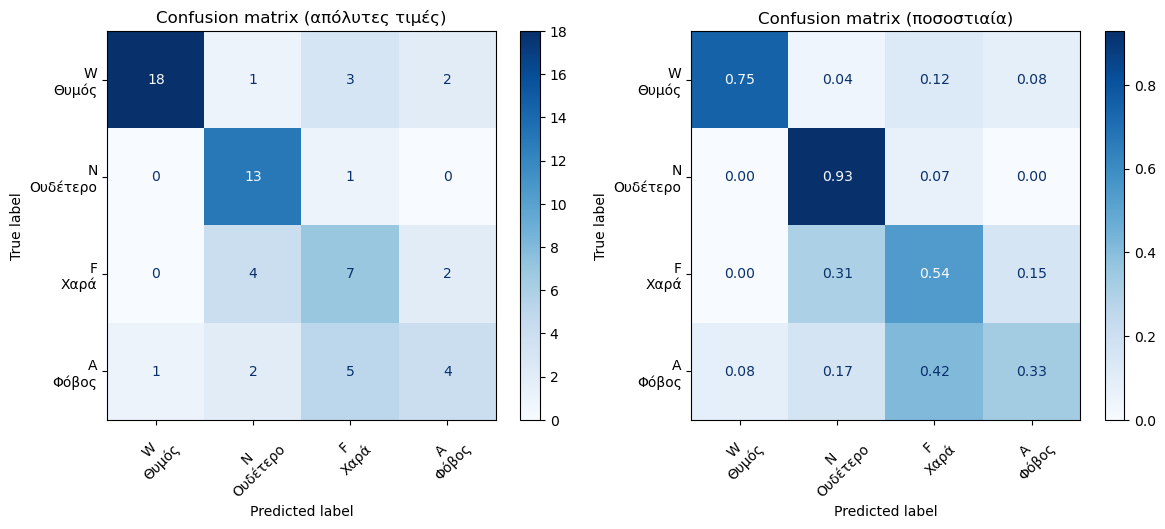

In [128]:
from sklearn.metrics import ConfusionMatrixDisplay

emo_order = ["W", "N", "F", "A"]
labels = [e for e in emo_order if e in set(y_test)]
display_labels = [f"{e}\n{EMO_MAP[e]}" for e in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=labels,
    display_labels=display_labels,
    xticks_rotation=45,
    normalize=None,
    values_format="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Confusion matrix (απόλυτες τιμές)")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=labels,
    display_labels=display_labels,
    xticks_rotation=45,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("Confusion matrix (ποσοστιαία)")

plt.tight_layout()
plt.show()

### Ερώτηση: Περιγράψτε στο παρακάτω κελι με λόγια το αποτέλεσμα των παραπάνω confusion matrices. Πώς αποδίδει το μοντέλο (RBF SVM) για κάθε συναίσθημα? Εξηγήστε αναλυτικά. 

### Απάντηση:

Ο αλγόριθμος αποδίδει εξαιρετικά για το ουδέτερο συναίσθημα και αρκετά καλά για το θυμό. Θα έλεγε κανείς ότι αποδίδει μέτρια για το συναίσθημα της χαράς, καθώς το "μπερδεύει" με αυτό του ουδέτερου, και η απόδοση στο συναίσθημα του φόβου είναι κοντά στο όριο του τυχαίου ($1/4=25\%$), που το "μπερδεύει" πολύ με τη χαρά και λιγότερο με το ουδέτερο.

---
---